---
title: "Week 4 Homework"
subtitle: DS 2023 | Communicating with Data
---

## Overview

In Week 4 you rebuilt the **Hertzsprung-Russell diagram** from Gaia data: a scatter plot in which
thousands of stars, plotted by color against absolute magnitude, stop being a cloud and resolve into
a **main sequence**, a giant branch, and a scattering of white dwarfs.

This homework asks you to do the same thing with countries.

In 1975 the economist **Samuel Preston** plotted national income against life expectancy and found the
same kind of structure: not a random cloud, but a curved band with a handful of conspicuous
departures from it. 

Hans Rosling later turned that plot into the most famous statistical graphic of
the last thirty years, and named his foundation after the warning you hear on the London
Underground: **Gapminder**.

Your job is to build that diagram, and to do the exploratory work that earns you the right to
draw it.

> [!NOTE] The H-R diagram and the Preston curve share a common structure.
>
> Both plot a **derived** quantity (absolute magnitude; GDP per capita) against an **observed** one
> (color index; life expectancy).
>
> Both need a **logarithmic** axis, because the underlying
> quantity spans several orders of magnitude. And in both, the scientific payoff is in the
> **shape of the point cloud**, not in any single point.

## Submitting your work 

After completing all the tasks in this notebook, restart the kernel and run all cells top to bottom before you submit. Make sure that all outputs are present and there are no errors.

Push the completed notebook to your GitHub repository and submit the URL to the homework assignment on Canvas.

## The data set

The **Gapminder** data set ships with Plotly Express. 

It contains $1{,}704$ observations: one row per country per year, for $142$ countries observed every five years from $1952$ to $2007$.

Here is the data dictionary:

| Column | Units | Description |
|---|---|---|
| `country` | — | Country name. |
| `continent` | — | One of `Africa`, `Americas`, `Asia`, `Europe`, `Oceania`. |
| `year` | year | Year of observation. Every fifth year, $1952$ through $2007$. |
| `lifeExp` | years | Life expectancy at birth. |
| `pop` | people | Total population. |
| `gdpPercap` | international dollars | GDP per capita, inflation-adjusted and PPP-adjusted so that values are comparable across countries and years. |
| `iso_alpha` | — | Three-letter ISO country code. |
| `iso_num` | — | Numeric ISO country code. We drop this one. |

To get the data, do this:

```python
from plotly.express import data as pxdata
gap = pxdata.gapminder()
```

## Tasks

Each task is worth 1 point.

Fractions will be given for partial credit.

### Task 1 

**Load and inspect the data.**

1. Import `pandas` as `pd`, `numpy` as `np`, `matplotlib.pyplot` as `plt`, and `seaborn` as `sns`.
2. Load the Gapminder data into a dataframe named `gap` and drop the `iso_num` column.
3. Display `.info()` and `.head()`.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from plotly.express import data as pxdata
gap = pxdata.gapminder()
gap = gap.drop("iso_num", axis = 1)
gap.info()
gap.head()

<class 'pandas.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   str    
 1   continent  1704 non-null   str    
 2   year       1704 non-null   int64  
 3   lifeExp    1704 non-null   float64
 4   pop        1704 non-null   int64  
 5   gdpPercap  1704 non-null   float64
 6   iso_alpha  1704 non-null   str    
dtypes: float64(2), int64(2), str(3)
memory usage: 93.3 KB


,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG


**Question.** Is this table tidy or wide? What is the unit of observation — that is, what does
a single row represent? Answer in one or two sentences.

**Answer:** This table is tidy because axis 0 is not a data column. A single row repsrents one obervation or data point in the entire data set.

### Task 2 

**Create derived columns**


In Week 4 you could not plot the H-R diagram until you turned apparent magnitude into **absolute**
magnitude, because a nearby dim star and a distant brilliant one can look equally bright. The same
move is needed here: raw numbers have to be converted into quantities that are comparable across
countries of wildly different sizes.

Add three columns to `gap`:

1. `gdp_total`: total GDP, computed as `gdpPercap * pop`.
2. `log_gdppc`: the base-$10$ logarithm of GDP per capita, computed with `np.log10()`.
3. `pop_m`: population in millions.

Then display the first five rows and answer the question.

In [63]:
gap['gdp_total'] = gap['gdpPercap']*gap['pop']
gap['log_gdppc'] = np.log10(gap['gdpPercap'])
gap['pop_m'] = gap['pop']/1000000
gap.info()
gap.head()
gap.query('country=="China" and year==2007 | country =="Norway" and year==2007')

<class 'pandas.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   str    
 1   continent  1704 non-null   str    
 2   year       1704 non-null   int64  
 3   lifeExp    1704 non-null   float64
 4   pop        1704 non-null   int64  
 5   gdpPercap  1704 non-null   float64
 6   iso_alpha  1704 non-null   str    
 7   gdp_total  1704 non-null   float64
 8   log_gdppc  1704 non-null   float64
 9   pop_m      1704 non-null   float64
dtypes: float64(5), int64(2), str(3)
memory usage: 133.3 KB


,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,gdp_total,log_gdppc,pop_m
299,China,Asia,2007,72.961,1318683096,4959.114854,CHN,6.539501e+12,3.695404,1318.683096
1151,Norway,Europe,2007,80.196,4627926,49357.190170,NOR,2.284214e+11,4.693350,4.627926


**Question.** In $2007$, China's `gdpPercap` is about $4{,}959$ and Norway's is about $49{,}357$. Which of the two has the larger `gdp_total`? 

Consider and keep as a mental note what this tells you about why we plot `gdpPercap` rather than `gdp_total` against life expectancy.

**Answer:** China had a larger gdp_total

### Task 3 

**Finding the extremes.** 

When you built the H-R diagram you used `.nsmallest()` to find the closest star in the sample.
Do the same kind of reconnaissance here.

1. Create a dataframe `gap07` containing only the observations from $2007$. Use `.query()`.
2. Show the five countries with the **highest** life expectancy in $2007$, along with their
   `gdpPercap`.
3. Show the five countries with the **lowest** life expectancy in $2007$, along with their
   `gdpPercap`.
4. Show the five countries with the **highest** `gdpPercap` in $2007$.

In [65]:
gap07 = gap.query('year==2007')
display(gap07.nlargest(5, "lifeExp")[["country", "lifeExp", "gdpPercap"]])
display(gap07.nsmallest(5, "lifeExp")[["country", "lifeExp", "gdpPercap"]])
display(gap07.nlargest(5, 'gdpPercap')[["country", "gdpPercap"]])

,country,lifeExp,gdpPercap
803,Japan,82.603,31656.06806
671,"Hong Kong, China",82.208,39724.97867
695,Iceland,81.757,36180.78919
1487,Switzerland,81.701,37506.41907
71,Australia,81.235,34435.36744


,country,lifeExp,gdpPercap
1463,Swaziland,39.613,4513.480643
1043,Mozambique,42.082,823.685621
1691,Zambia,42.384,1271.211593
1355,Sierra Leone,42.568,862.540756
887,Lesotho,42.592,1569.331442


,country,gdpPercap
1151,Norway,49357.19017
863,Kuwait,47306.98978
1367,Singapore,47143.17964
1619,United States,42951.65309
755,Ireland,40675.99635


**Question.** At least one country appears in the richest five but not in the longest-lived five.
Name it and say what that mismatch suggests about the relationship you are about to plot.

**Answer:** Actually every country in the richest 5 fails to appear in the longest-lived 5, but to name a specific one, Norway follows this trend. This mismatch may suggest a low or non-existent correlation betwen gdpPercap and lifeExp.

### Task 4 

**Composition: pie and bar charts.**

Work with `gap07` for this task.

1. Create a pie chart of the number of countries per continent.
2. Recreate the pie chart with the **largest** wedge exploded by $0.1$ and the start angle set to
   $90$ degrees. Build the explode list programmatically — do not hard-code the number of
   continents.
3. Create a bar chart of the **mean** `lifeExp` by continent, sorted from lowest to highest, with
   horizontal x tick labels.
4. Add value labels to the top of each bar, formatted to one decimal place.

> [!tip] For the labels: `ax.bar_label(ax.containers[0], fmt='%.1f')`

<Axes: title={'center': 'Number of Countries per Continent (2007)'}>

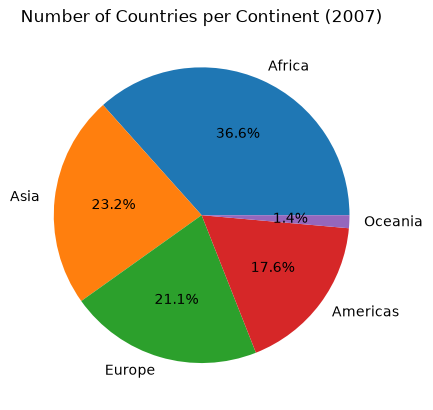

In [43]:
#1
counts = gap07["continent"].value_counts()
counts.plot.pie(autopct="%1.1f%%", title = "Number of Countries per Continent (2007)")

<Axes: title={'center': 'Number of Countries per Continent (2007)'}>

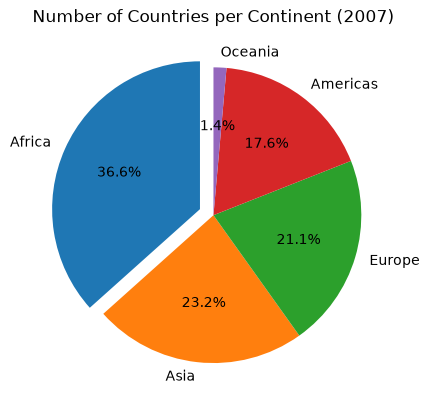

In [51]:
#2

counts.plot.pie(autopct="%1.1f%%", 
                title = "Number of Countries per Continent (2007)",
                explode = [0.1 if value == counts.max() else 0 for value in counts],
               startangle=90)

[Text(0, 0, '54.8'),
 Text(0, 0, '70.7'),
 Text(0, 0, '73.6'),
 Text(0, 0, '77.6'),
 Text(0, 0, '80.7')]

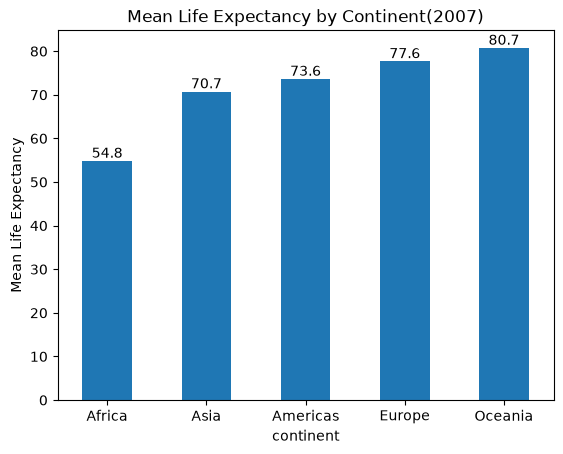

In [68]:
#3 and 4
mean_lifeExp = gap07.groupby("continent")["lifeExp"].mean().sort_values()
ax = mean_lifeExp.plot.bar(rot=0, title="Mean Life Expectancy by Continent(2007)", ylabel="Mean Life Expectancy")
ax.bar_label(ax.containers[0], fmt='%.1f')

**Question.** The pie chart and the bar chart both describe continents, but they answer different
questions. State the question each one answers, and explain why the pie chart would be the wrong
chart for the mean life expectancy figures.

**Answer:** The pie chart answers the question "How many of the total world's countries belong to each continent relative to all other continents?" and the bar chart answers the question "What is the average life expectancy of each continent?". The pie chart would be the incorrect representation because they represent things in relation to a whole, and there is no cumulative life expectancy.

### Task 5 

**Grouped bar charts**

1. Create a dataframe holding the mean `lifeExp` for each combination of `continent` and `year`,
   restricted to the years $1952$, $1977$, and $2007$. Use `.groupby()` with `.unstack()`, or
   `.pivot_table()`.
2. Plot it as a grouped bar chart with **continent** on the x axis and one bar color per year.
3. Plot the same data as a grouped bar chart with **year** on the x axis and one bar color per
   continent.

Both charts should have horizontal x tick labels and a title.

year,1952,1957,1962,1967,1972,1977,1982,1987,1992,1997,2002,2007
continent,,,,,,,,,,,,
Africa,39.135500,41.266346,43.319442,45.334538,47.450942,49.580423,51.592865,53.344788,53.629577,53.598269,53.325231,54.806038
Americas,53.279840,55.960280,58.398760,60.410920,62.394920,64.391560,66.228840,68.090720,69.568360,71.150480,72.422040,73.608120
Asia,46.314394,49.318544,51.563223,54.663640,57.319269,59.610556,62.617939,64.851182,66.537212,68.020515,69.233879,70.728485
Europe,64.408500,66.703067,68.539233,69.737600,70.775033,71.937767,72.806400,73.642167,74.440100,75.505167,76.700600,77.648600
Oceania,69.255000,70.295000,71.085000,71.310000,71.910000,72.855000,74.290000,75.320000,76.945000,78.190000,79.740000,80.719500


year,1952,1977,2007
continent,,,
Africa,39.135500,49.580423,54.806038
Americas,53.279840,64.391560,73.608120
Asia,46.314394,59.610556,70.728485
Europe,64.408500,71.937767,77.648600
Oceania,69.255000,72.855000,80.719500


<Axes: title={'center': 'Mean Life Expectancy in Every Continent Across 3 Different Years'}, xlabel='year', ylabel='Mean Life Expectancy'>

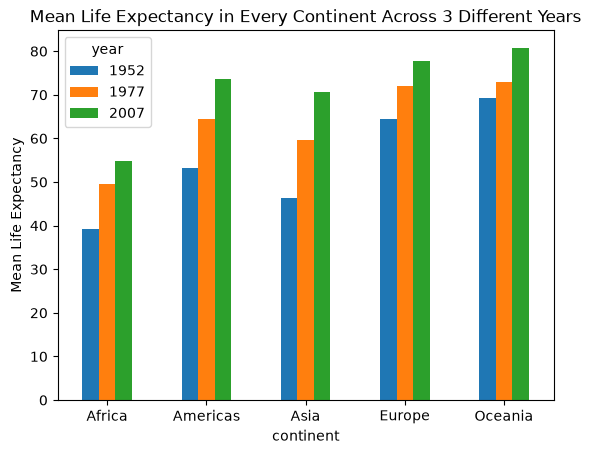

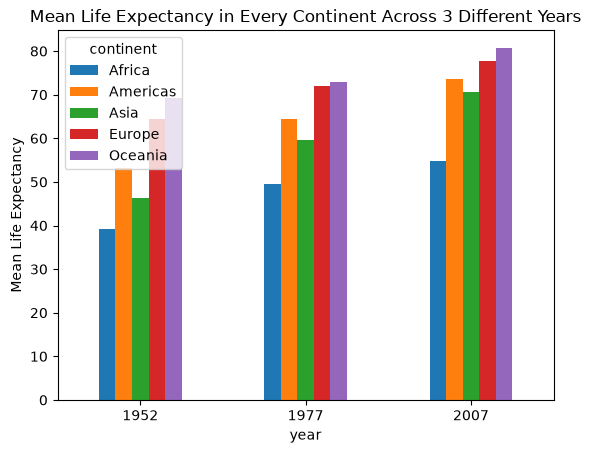

In [85]:
gap_pivot = gap.pivot_table(index = 'continent', columns = 'year', values = 'lifeExp', aggfunc ='mean')
display(gap_pivot)
gap3yrs = gap_pivot[[1952,1977,2007]]
display(gap3yrs)

gap3yrs.plot.bar(rot=0, ylabel='Mean Life Expectancy', title='Mean Life Expectancy in Every Continent Across 3 Different Years')

gap3yrs.T.plot.bar(rot=0, ylabel='Mean Life Expectancy', title='Mean Life Expectancy in Every Continent Across 3 Different Years')


**Question.** The two charts contain identical numbers. Which comparison does each one make easy,
and which continent's trajectory is hardest to read in the second chart? Why?

**Answer:** The first one makes it easier to comapre between continents and the second one makes it easier to compare years. I would say that asia's trajectory is the hardest to read because it is sandwhiched in the middle and lower than its surrounding continents.

### Task 6

**Line graphs with two y axes.**

Create a **single** figure showing how mean life expectancy and mean GDP per capita have changed
over the whole period. Your plot must meet all of these requirements:

1. `year` on the x axis, using the mean across all countries for each year.
2. `lifeExp` on the **left** y axis, drawn as a red line.
3. `gdpPercap` on the **right** y axis, drawn as a blue line.
4. Both y axes labeled with their variable names.
5. A figure size of $10$ by $5$, a title, and legends that do not overlap each other.

> [!tip] Use `plt.twinx(ax)` or `ax.twinx()` to create the second axes object.

,gdpPercap,lifeExp
year,,
1952,3725.276046,49.057620
1957,4299.408345,51.507401
1962,4725.812342,53.609249
1967,5483.653047,55.678290
1972,6770.082815,57.647386
1977,7313.166421,59.570157
1982,7518.901673,61.533197
1987,7900.920218,63.212613
1992,8158.608521,64.160338


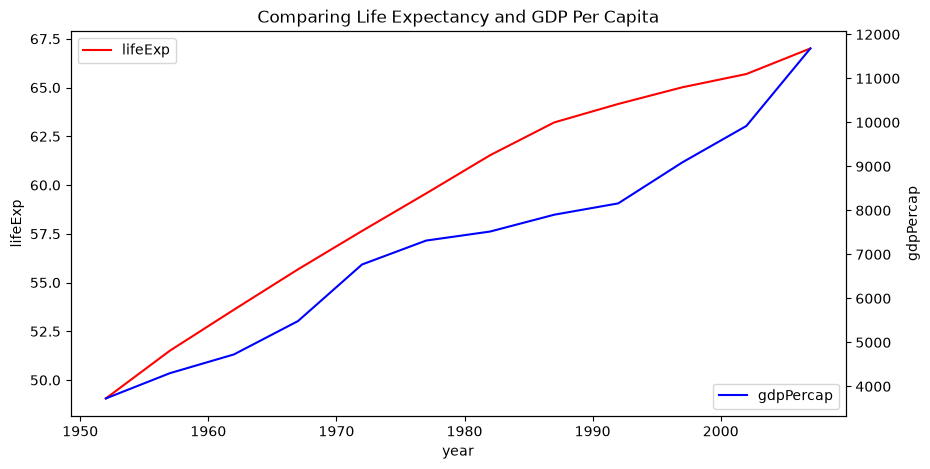

In [110]:
gap_pivot2 = gap.pivot_table(index = 'year', values = ['lifeExp', 'gdpPercap'], aggfunc ='mean')
display(gap_pivot2)

ax = gap_pivot2['lifeExp'].plot(color = 'red', legend=False, figsize=(10,5))
ax2 = ax.twinx()
gap_pivot2['gdpPercap'].plot(ax=ax2, color='blue', legend=False,)
ax.set_ylabel('lifeExp'), ax2.set_ylabel('gdpPercap')
plt.title("Comparing Life Expectancy and GDP Per Capita")
ax.legend(loc="upper left")
ax2.legend(loc="lower right")
plt.show()

### Task 7

**Area and difference charts** 

In Week 4 you built a difference chart of US agricultural imports and exports by
plotting two unstacked area charts and masking the overlap with a white area chart. Use that
pattern here.

1. Build a dataframe with `year` as the index and one column each for `Africa` and `Europe`, holding
   the mean `lifeExp` for that continent in that year.
2. Plot both columns as an **unstacked** area chart, figure size $12$ by $6$, with the y axis
   starting at $0$.
3. Turn it into a **difference chart** by plotting the row-wise minimum as a white area chart on the
   same axes.

> [!tip] The mask is `pair.min(axis=1)`, plotted with `.plot.area(ax=ax, color='white', lw=0)`.
>
> If you would rather use `ax.fill_between(..., where=...)`, that is also accepted for
> requirement $3$.

<Axes: xlabel='year'>

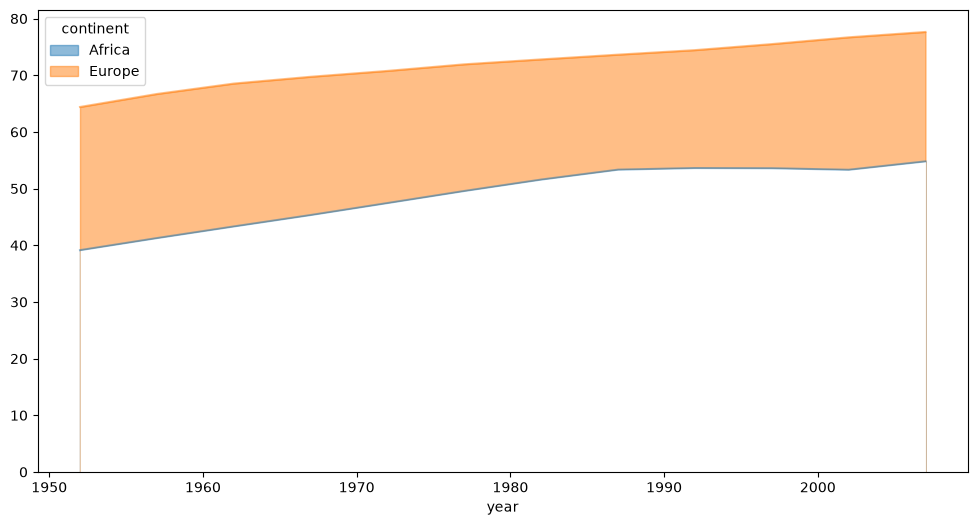

In [120]:
gap_years = gap.query("continent=='Africa' | continent=='Europe'").pivot_table(index = 'year', columns = 'continent', values = 'lifeExp', aggfunc = 'mean')
gap_years.head()

ax = gap_years[['Africa','Europe']].plot.area(stacked=False, figsize=(12,6), ylim=0)
display(ax)

gap_years['min'] = gap_years[['Africa','Europe']].min(axis=1)
gap_years['min'].plot.area(ax=ax, color='white', lw=0)
plt.show()

### Task 8

**Choosing the axis scale.**

Sort the $2007$ observations by `gdpPercap` from lowest to highest, reset the index, and plot the values as a line. The x axis is the rank of the country; the y axis is the value.

Then plot the same series again with `logy=True`.

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,gdp_total,log_gdppc,pop_m
0,"Congo, Dem. Rep.",Africa,2007,46.462,64606759,277.551859,COD,1.793173e+10,2.443344,64.606759
1,Liberia,Africa,2007,45.678,3193942,414.507341,LBR,1.323912e+09,2.617532,3.193942
2,Burundi,Africa,2007,49.580,8390505,430.070692,BDI,3.608510e+09,2.633540,8.390505
3,Zimbabwe,Africa,2007,43.487,12311143,469.709298,ZWE,5.782658e+09,2.671829,12.311143
4,Guinea-Bissau,Africa,2007,46.388,1472041,579.231743,GNB,8.526529e+08,2.762852,1.472041


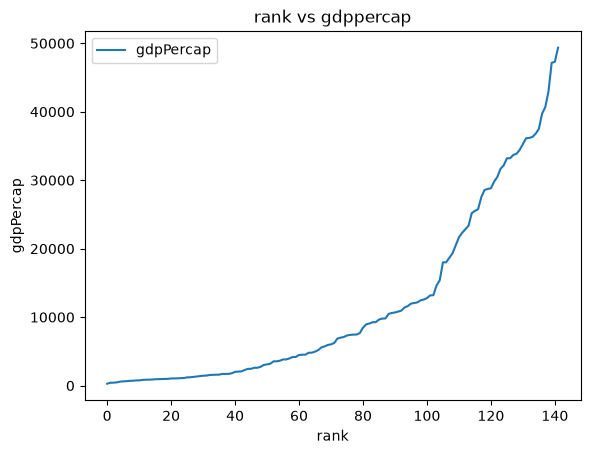

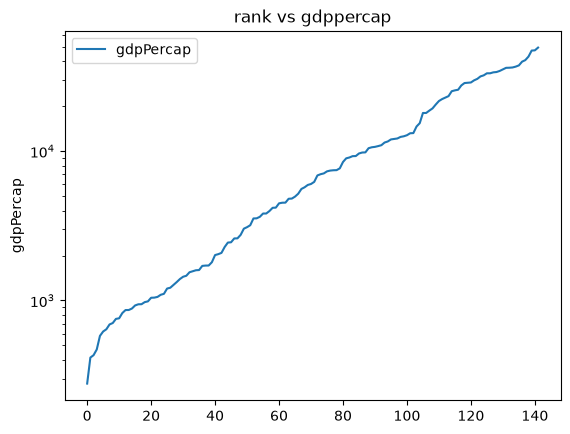

In [123]:
sortedgap = gap.query("year==2007")
sortedgap = sortedgap.sort_values( by = 'gdpPercap', ascending = True)
sortedgap = sortedgap.reset_index()
sortedgap = sortedgap.drop('index', axis = 1)
display(sortedgap.head())
sortedgap.plot(y = 'gdpPercap', xlabel = 'rank', ylabel = 'gdpPercap', title = 'rank vs gdppercap')
plt.show()
sortedgap.plot(y = 'gdpPercap', logy = True, ylabel = 'gdpPercap', title = 'rank vs gdppercap')
plt.show()

### Task 9

**Creating an H-R diagram of nations.**

Use the **entire** `gap` dataframe, all $1{,}704$ observations, not just $2007$.

Create a scatter plot with `gdpPercap` on the x axis and `lifeExp` on the y axis.

Use a logarithmic x axis; pass `logx=True` to the plot method.

Use small, semi-transparent black points, since there are thousands of them. Try `s=3` and `alpha=0.3`.

Set the figure size of $8$ by $7$.

Set the title to "Life expectancy against income, 1952-2007".

<Axes: title={'center': 'Life expectancy against income, 1952-2007'}, xlabel='gdpPercap', ylabel='lifeExp'>

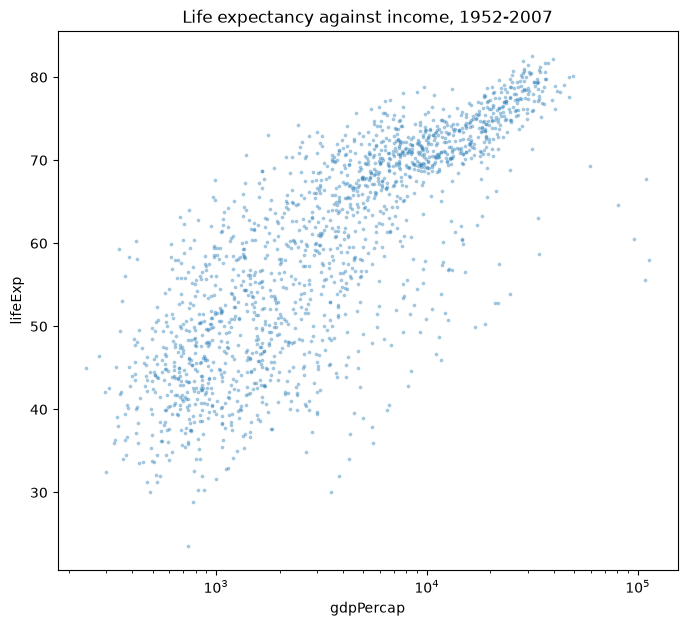

In [124]:
gap.plot.scatter(x = 'gdpPercap', y = 'lifeExp', logx = True, s=3, alpha = 0.3, figsize = (8,7), title = 'Life expectancy against income, 1952-2007')

### Task 10

Recreate the preceding plot with the following changes:

Wrap the plotting code in `with plt.style.context("dark_background"):` so the figure gets a dark background.

Color each point by `log_gdppc` using a blue-to-red colormap. Try `cmap="RdYlBu_r"`.

Size each point by `pop_m` so that populous countries read as bright, heavy points. Scale the values so that the largest circles do not swallow the plot — `s=gap['pop_m'] / 2` is a reasonable starting point.

Set `linewidths=0`, a figure size of $11$ by $8$, an alpha around $0.6$.

Finally, set the title to "The wealth and health of nations, 1952-2007".

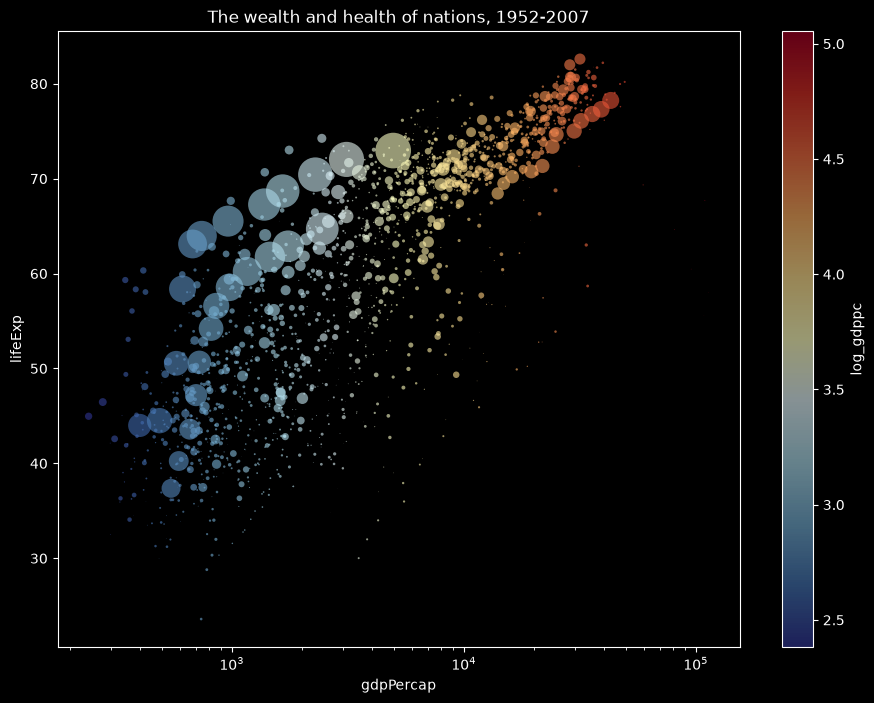

In [125]:
with plt.style.context("dark_background"):
    gap.plot.scatter(x = 'gdpPercap', y = 'lifeExp', logx = True,  title = 'The wealth and health of nations, 1952-2007', figsize = (11,8), cmap = "RdYlBu_r", c = 'log_gdppc', s = gap['pop_m']/2, lw = 0, alpha = 0.6)